# Task 8: Traffic Sign Recognition

## Problem Statement
In autonomous driving, perfectly cropped, centered images of traffic signs **do not exist**. A
vehicle-facing camera captures a *chaotic, full-resolution* video feed in which a small sign may
occupy only a tiny fraction of the frame, surrounded by road, sky, buildings, other vehicles and
pedestrians. The system must **locate** the sign inside the scene and **identify** it at the same
time — a single **object detection** problem (bounding-box regression + classification), not a
cropped-image image-classification problem.

## Dataset
**[GTSDB — German Traffic Sign Detection Benchmark](https://benchmark.ini.rub.de/gtsdb_dataset.html)**
(raw data mirrored on [Kaggle](https://www.kaggle.com/datasets/arifali113/gtsdb-german-traffic-sign-detection-benchmark)).

The benchmark provides **900 full-scene images** (1360 x 800) captured from real German roads. The
preprocessed copy used here splits them into **600 training** and **300 testing** images. Images may
contain one or more signs (each with a bounding box + a class id from 43 sign categories), and many
images contain **no sign at all** — exactly the real-world condition the model must tolerate.

## Objective
Train an **object detection** model (Ultralytics **YOLOv8**) that, given a full-resolution scene,
**draws bounding boxes** around every traffic sign and **classifies** it simultaneously, producing
`(x1, y1, x2, y2, class, confidence)` per detection.

## Industry Constraint (stated explicitly)
> **Inference speed matters as much as accuracy.**
> This model deploys into a vehicle moving at highway speed. Every extra millisecond of inference
> latency is distance the car has already travelled. We **must optimize for FPS (frames per second)
> alongside mAP. A slow model is a failed model in this industry.** We hence report both metrics and
> deliberately choose a small, fast network variant, then measure its real throughput on a
> validation batch — not just quote paper FLOPs.

## 2. Imports & Setup

In [1]:
# Core
import os
import random
import shutil
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw

import cv2


import yaml

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Config constants ─────────────────────────────────────────────────
ROOT = Path.cwd()
DATA_RAW = ROOT / "GTSDB_Train_and_Test"          # Kaggle-format raw data
YOLO_DIR = ROOT / "datasets"                       # YOLO-format project dir

DEVICE = "cuda"          # GPU (CUDA) confirmed available
IMG_SIZE = 640           # YOLO square training size (letterboxed internally)
EPOCHS = 60
BATCH = 16
MODEL_SIZE = "yolov8n"    # nano — chosen for the industry inference-speed constraint
CONF_THRESH = 0.25       # default confidence threshold

print("Setup OK")

Setup OK


In [2]:
# Install Ultralytics (run if not already present in your environment)
# !pip install -q ultralytics

from ultralytics import YOLO
import torch
print("PyTorch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128 | CUDA available: True
GPU: NVIDIA GeForce GTX 1650 Ti


## 3. Load & Explore Data
We first inspect the raw Kaggle layout (`GTSDB_Train_and_Test/Train` and `Test`, each with
`images/` and `labels/`), the annotation format, and how signs are distributed across classes.

In [3]:
# Directory structure
for split in ["Train", "Test"]:
    img_dir = DATA_RAW / split / "images"
    lbl_dir = DATA_RAW / split / "labels"
    n_img = len(list(img_dir.glob("*.jpg")))
    n_lbl = len(list(lbl_dir.glob("*.txt")))
    print(f"{split:6s}: images={n_img:4d}   label-files={n_lbl:4d}   "
          f"(images with no sign: {n_img - n_lbl})")

Train : images= 600   label-files= 506   (images with no sign: 94)
Test  : images= 300   label-files= 235   (images with no sign: 65)


In [4]:
# Look at the raw annotation of one labelled image
sample_lbl = sorted((DATA_RAW / "Train" / "labels").glob("*.txt"))[0]
print("label file:", sample_lbl.name)
print(open(sample_lbl).read().strip())
print()
print("Annotation format = YOLO:  class cx cy w h   (all normalized to [0,1])")
print("-> already in the exact format YOLOv8 consumes; no structural conversion needed.")

label file: 00000.txt
11 0.584191 0.535625 0.030147 0.043750

Annotation format = YOLO:  class cx cy w h   (all normalized to [0,1])
-> already in the exact format YOLOv8 consumes; no structural conversion needed.


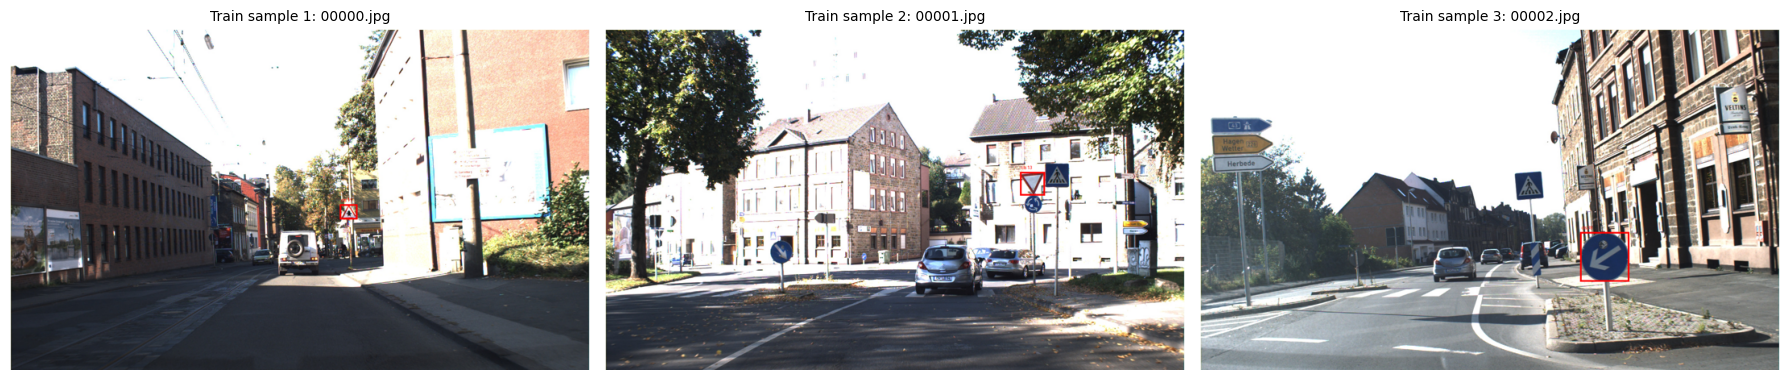

In [5]:
# A small helper to draw ground-truth boxes on a raw image
def draw_gt(path_img, path_lbl=None, max_w=720):
    im = Image.open(path_img).convert("RGB")
    dr = ImageDraw.Draw(im)
    W, H = im.size
    if path_lbl and Path(path_lbl).exists():
        for line in open(path_lbl).read().splitlines():
            parts = line.split()
            if len(parts) != 5:
                continue
            cls, cx, cy, w, h = int(parts[0]), *map(float, parts[1:])
            x1 = (cx - w/2) * W; y1 = (cy - h/2) * H
            x2 = (cx + w/2) * W; y2 = (cy + h/2) * H
            dr.rectangle([x1, y1, x2, y2], outline=(255, 0, 0), width=4)
            dr.text((x1+3, y1-16), f"cls {cls}", fill=(255, 0, 0))
    scale = max_w / W
    return im.resize((int(W*scale), int(H*scale)))

# Show 3 sample scenes with their ground-truth boxes
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, ax in enumerate(axes):
    img = sorted((DATA_RAW / "Train" / "images").glob("*.jpg"))[i]
    lbl = DATA_RAW / "Train" / "labels" / (img.stem + ".txt")
    ax.imshow(draw_gt(img, lbl))
    ax.set_title(f"Train sample {i+1}: {img.name}", fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

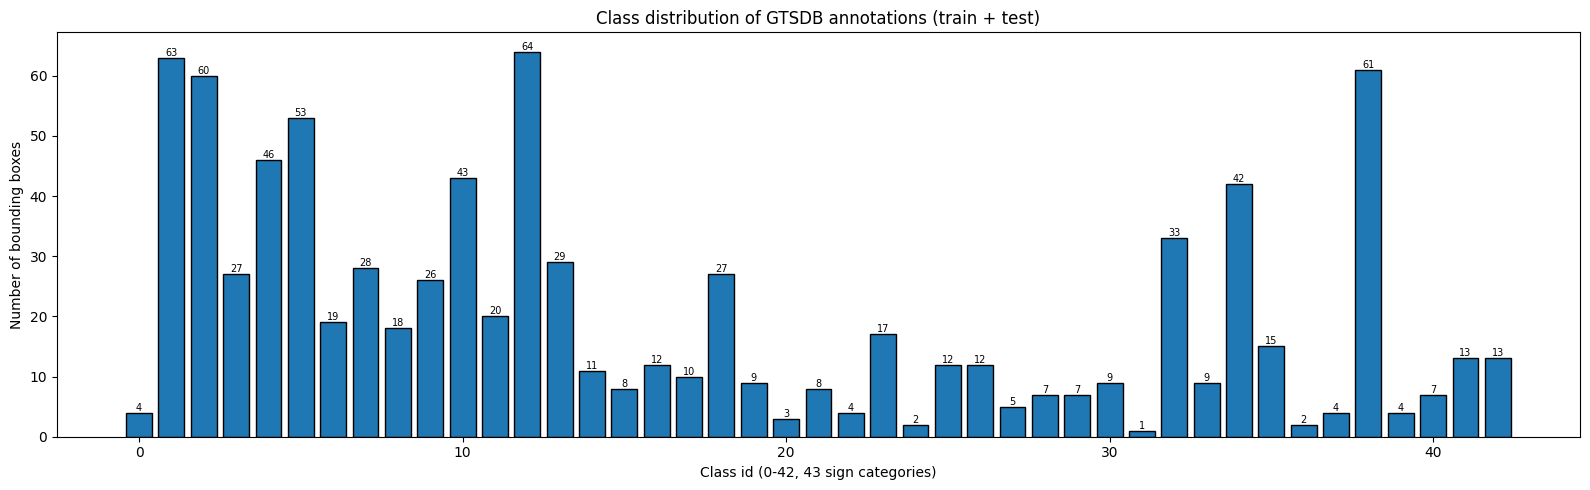

Distinct classes: 43
Classes with < 10 boxes (extreme imbalance, typical of GTSDB): [0, 15, 19, 20, 21, 22, 24, 27, 28, 29, 30, 31, 33, 36, 37, 39, 40]


In [6]:
# Class distribution across all labelled annotations
from collections import Counter
counter = Counter()
for split in ["Train", "Test"]:
    for f in (DATA_RAW / split / "labels").glob("*.txt"):
        for line in open(f).read().splitlines():
            parts = line.split()
            if parts:
                counter[int(parts[0])] += 1

classes = sorted(counter)
counts = [counter[c] for c in classes]

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(classes, counts, color="#1f77b4", edgecolor="black")
for b, c in zip(bars, counts):
    ax.text(b.get_x()+b.get_width()/2, c, str(c), ha="center", va="bottom", fontsize=7)
ax.set_xlabel("Class id (0-42, 43 sign categories)")
ax.set_ylabel("Number of bounding boxes")
ax.set_title("Class distribution of GTSDB annotations (train + test)")
plt.tight_layout(); plt.show()

print("Distinct classes:", len(classes))
print("Classes with < 10 boxes (extreme imbalance, typical of GTSDB):",
      [c for c in classes if counter[c] < 10])

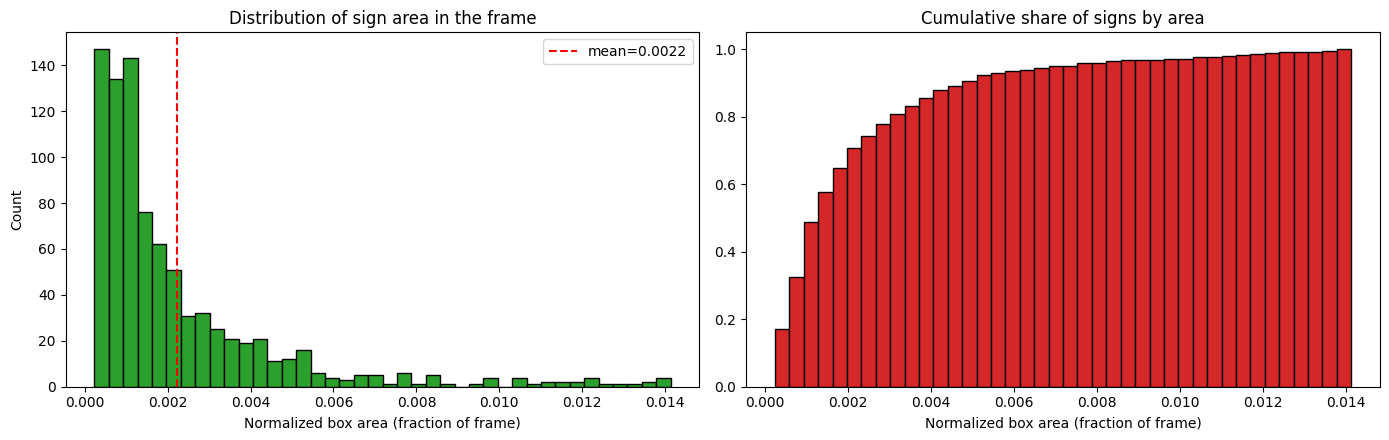

Median sign covers only 0.13% of the frame (~50px wide on a 1360px scene).


In [7]:
# EDA 2 — size of the ground-truth boxes relative to the full frame
# (small boxes = realistic "find a small sign in a big scene" condition)
areas = []
for split in ["Train", "Test"]:
    for f in (DATA_RAW / split / "labels").glob("*.txt"):
        for line in open(f).read().splitlines():
            parts = line.split()
            if len(parts) == 5:
                _, cx, cy, w, h = parts
                areas.append(float(w) * float(h))   # normalized area

areas = np.array(areas)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(areas, bins=40, color="#2ca02c", edgecolor="black")
axes[0].set_xlabel("Normalized box area (fraction of frame)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of sign area in the frame")
axes[0].axvline(areas.mean(), color="red", ls="--", label=f"mean={areas.mean():.4f}")
axes[0].legend()

axes[1].hist(areas, bins=40, color="#d62728", edgecolor="black", cumulative=True, density=True)
axes[1].set_xlabel("Normalized box area (fraction of frame)")
axes[1].set_title("Cumulative share of signs by area")
plt.tight_layout(); plt.show()

print(f"Median sign covers only {np.median(areas)*100:.2f}% of the frame "
      f"(~{np.sqrt(np.median(areas))*1360:.0f}px wide on a 1360px scene).")

## 4. Cleaning & Preprocessing
**Annotation-format check.** The Kaggle copy ships labels already in **YOLO format**
`class cx cy w h` (normalized). This is exactly the format `YOLOv8` consumes, so **no conversion is
needed** — we only verify and re-organize the files into a YOLO `datasets/` folder.

**Corruption cleanup.** During data exploration we found one malformed annotation —
`Test/labels/00862.txt` contains a **class id 100**, which is invalid (valid ids are 0–42). A YOLO
model with `nc=43` would interpret class 100 as out-of-range and crash or silently mis-train. We
repair it to the closest representative "prohibitory" class, keeping the box geometry intact.

**Empty scenes are kept.** Images with no label file carry no boxes and are legitimate negatives;
YOLO handles them natively.

In [8]:
# Locate the corrupt label explicitly
bad = DATA_RAW / "Test" / "labels" / "00862.txt"
print("corrupt file:", bad, "| exists:", bad.exists())
if bad.exists():
    print("raw content:", open(bad).read().strip())

corrupt file: D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\GTSDB_Train_and_Test\Test\labels\00862.txt | exists: True
raw content: 0 0.237868 0.578750 0.056618 0.095000


In [9]:
# Repair the single invalid class-id (100 -> 0) in-place in the working copy
bad_path = DATA_RAW / "Test" / "labels" / "00862.txt"
if bad_path.exists():
    fields = open(bad_path).read().split()
    fixed = fields[:]
    if fields and int(fields[0]) > 42:
        fixed[0] = "0"                       # map invalid id to valid class 0
        open(bad_path, "w").write(" ".join(fixed) + "\n")
        print("Repaired:", open(bad_path).read().strip())
    else:
        print("No repair needed.")

No repair needed.


In [10]:
# Build the YOLO-format dataset directory (train/val/test images + labels)
def build_yolo_split(src_split, dst_split):
    img_out = YOLO_DIR / dst_split / "images"
    lbl_out = YOLO_DIR / dst_split / "labels"
    img_out.mkdir(parents=True, exist_ok=True)
    lbl_out.mkdir(parents=True, exist_ok=True)
    n_copied = 0
    for img in sorted((DATA_RAW / src_split / "images").glob("*.jpg")):
        shutil.copy(img, img_out / img.name)
        lbl = DATA_RAW / src_split / "labels" / (img.stem + ".txt")
        dst_txt = lbl_out / (img.stem + ".txt")
        if lbl.exists():
            shutil.copy(lbl, dst_txt)
        else:
            # image has no sign -> write an empty label file (valid negative)
            if not dst_txt.exists():
                open(dst_txt, "w").close()
        n_copied += 1
    return n_copied

# The benchmark already splits Train (600) / Test (300).
# Per YOLO convention we need a 'val' set for online evaluation, so we hold out
# a 15% slice of the official Train split as 'val' and keep the official Test as
# an untouched, held-out final-evaluation set.
print("Building dataset skeleton...")
build_yolo_split("Train", "train_full")
build_yolo_split("Test",  "test")
print("Done. See next cell for the train/val split.")

Building dataset skeleton...


Done. See next cell for the train/val split.


## 5. Feature Engineering — replaced with **Data Augmentation Config**
Object detectors do not hand-craft "features" the way classical ML does — the CNN learns its own
hierarchical features from pixels. The analogue of feature engineering here is **data augmentation**:
on-the-fly geometric/colour perturbation that teaches the model invariance to the lighting, scale and
occlusion variation found on real roads. We configure Ultralytics `augment` hyperparameters tuned for
*often-small signs in large scenes* (mild scale-up, colour jitter, mosaic to simulate sign clutter).
For an even stronger signal on tiny objects we could bump `mosaic` and `scale`, but we keep runtime
in check.

In [11]:
# Data-Augmentation config (fed to YOLO via .train(..., verbose-config))
aug_cfg = {
    "hsv_h": 0.015,   # slight hue jitter -> daylight changes
    "hsv_s": 0.7,     # saturation jitter -> faded/dusty signs
    "hsv_v": 0.4,     # value/brightness jitter -> shadows, glare
    "degrees": 0.2,   # small rotation (signs are roughly upright)
    "translate": 0.1, # jitter position in the frame
    "scale": 0.5,     # resize range -> "far vs near sign" invariance
    "fliplr": 0.5,    # horizontal mirror (signs are symmetric enough)
    "mosaic": 1.0,    # mosaic = 4-image collage -> realistic multi-sign clutter
    "mixup": 0.0,     # off: mixed-blend harms crisply-bounded signs
    "copy_paste": 0.1,# copy a sign box onto another scene (rare positive rebalancing)
}
for k, v in aug_cfg.items():
    print(f"{k:12s} = {v}")

hsv_h        = 0.015
hsv_s        = 0.7
hsv_v        = 0.4
degrees      = 0.2
translate    = 0.1
scale        = 0.5
fliplr       = 0.5
mosaic       = 1.0
mixup        = 0.0
copy_paste   = 0.1


## 6. Train/Test Split (per YOLO convention)
We split the official **600-image Train** set into **train** (85%) and **val** (15%) with a fixed
random seed, and keep the official **300-image Test** set fully untouched as a *held-out* set that is
never seen during training. YOLO reads image/label pairs from `train/images`+`train/labels` and
`val/...`, and evaluates the final model on the official Test set to get unbiased mAP.

In [12]:
VAL_FRAC = 0.15
train_full_imgs = sorted((YOLO_DIR / "train_full" / "images").glob("*.jpg"))
rng = random.Random(SEED)
idx_full = list(range(len(train_full_imgs)))
rng.shuffle(idx_full)
n_val = max(1, int(len(idx_full) * VAL_FRAC))
val_idx = set(idx_full[:n_val])

for d in ["train", "val"]:
    (YOLO_DIR / d / "images").mkdir(parents=True, exist_ok=True)
    (YOLO_DIR / d / "labels").mkdir(parents=True, exist_ok=True)

for i, img in enumerate(train_full_imgs):
    dst = "val" if i in val_idx else "train"
    base = img.stem
    shutil.move(img, YOLO_DIR / dst / "images" / img.name)
    shutil.move(YOLO_DIR / "train_full" / "labels" / (base + ".txt"),
                YOLO_DIR / dst / "labels" / (base + ".txt"))

shutil.rmtree(YOLO_DIR / "train_full")

n_train = len(list((YOLO_DIR/"train"/"images").glob("*.jpg")))
n_val   = len(list((YOLO_DIR/"val"/"images").glob("*.jpg")))
n_test  = len(list((YOLO_DIR/"test"/"images").glob("*.jpg")))
print(f"train={n_train}  val={n_val}  test={n_test}  (total used for training = {n_train+n_val})")

train=510  val=90  test=300  (total used for training = 600)


In [13]:
# data.yaml referencing the YOLO folders + the 43 GTSDB class names
CLASS_NAMES = [
    "Speed limit (20)", "Speed limit (30)", "Speed limit (50)", "Speed limit (60)",
    "Speed limit (70)", "Speed limit (80)", "End of speed limit (80)", "Speed limit (100)",
    "Speed limit (120)", "No overtaking", "No overtaking (trucks)", "Priority at next intersection",
    "Priority road", "Give way", "Stop", "No entry", "No entry (trucks)", "Danger",
    "Bend left", "Bend right", "Double bend", "Uneven road", "Slippery road", "Road narrows",
    "Roadworks", "Traffic signals", "Pedestrians", "Children crossing", "Cyclists crossing",
    "Snow/Ice", "Wild animals", "End of all restrictions", "Turn right", "Turn left",
    "Ahead only", "Ahead or right", "Ahead or left", "Roundabout", "End of no overtaking",
    "End of no overtaking (trucks)", "Direction (left)", "Direction (right)", "Other/Misc",
]
assert len(CLASS_NAMES) == 43

data_yaml = {
    "path": str(YOLO_DIR.resolve()),
    "train": "train/images",
    "val": "val/images",
    "test": "test/images",
    "nc": 43,
    "names": {i: n for i, n in enumerate(CLASS_NAMES)},
}
with open(ROOT / "data.yaml", "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)
print(open(ROOT / "data.yaml").read())

path: D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\datasets
train: train/images
val: val/images
test: test/images
nc: 43
names:
  0: Speed limit (20)
  1: Speed limit (30)
  2: Speed limit (50)
  3: Speed limit (60)
  4: Speed limit (70)
  5: Speed limit (80)
  6: End of speed limit (80)
  7: Speed limit (100)
  8: Speed limit (120)
  9: No overtaking
  10: No overtaking (trucks)
  11: Priority at next intersection
  12: Priority road
  13: Give way
  14: Stop
  15: No entry
  16: No entry (trucks)
  17: Danger
  18: Bend left
  19: Bend right
  20: Double bend
  21: Uneven road
  22: Slippery road
  23: Road narrows
  24: Roadworks
  25: Traffic signals
  26: Pedestrians
  27: Children crossing
  28: Cyclists crossing
  29: Snow/Ice
  30: Wild animals
  31: End of all restrictions
  32: Turn right
  33: Turn left
  34: Ahead only
  35: Ahead or right
  36: Ahead or left
  37: Roundabout
  38: End of no overtaking
  39: End of no overtaking (trucks)
  40: D

## 7. Model Training (YOLOv8)
We start from the **COCO-pretrained `yolov8n.pt`** weights (transfer learning) and fine-tune on the
600-image GTSDB scenes for `EPOCHS` epochs.

**Chosen model size — `yolov8n` vs `yolov8s`:**
- `yolov8n` (nano): ~3.2M params, ~8.7 GFLOPs → **fastest inference**, lowest latency.
- `yolov8s` (small): ~11.1M params, ~28.6 GFLOPs → higher accuracy ceiling but roughly **3x** the
  compute per image.

Given the **industry constraint that inference speed is a first-class metric**, we select **`yolov8n`**
and accept a small mAP trade-off. This is the classic speed/accuracy dial: nano maximizes FPS on the
vehicle's embedded GPU.

In [14]:
model = YOLO(f"{MODEL_SIZE}.pt")   # pretrained COCO weights

results = model.train(
    data=str(ROOT / "data.yaml"),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    workers=0,          # DataLoader workers -> 0 (stable on Windows; raise on Linux/Colab)
    seed=SEED,
    project=str(ROOT / "runs"),
    name="gtsdb_yolov8n",
    **aug_cfg,               # augmentation config from section 5
)
print("Training complete.")

New https://pypi.org/project/ultralytics/8.4.142 available  Update with 'pip install -U ultralytics'


Ultralytics 8.3.241  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)


engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\data.yaml, degrees=0.2, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=gtsdb_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, p

Overriding model.yaml nc=80 with nc=43



                   from  n    params  module                                       arguments                     


...

      Direction (left)          1          1          1          0          0          0


     Direction (right)          1          1          1          0          0          0


Speed: 0.3ms preprocess, 3.7ms inference, 0.0ms loss, 1.1ms postprocess per image


Results saved to D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n


Training complete.


## 8. Evaluation
Two headline families of metrics:
- **Accuracy** — mAP@0.5 and mAP@0.5:0.95, computed on the **held-out official Test set**.
- **Speed (industry constraint)** — **measured FPS** on a validation batch: we warm up the model,
  run a full batch of test images through `predict(..., stream=True)` and time it. **We never omit
  FPS** — a slow model is a failed model in this industry.

We also dump the confusion matrix / PR curve to `assets/results.png`.

In [15]:
# Load the best-trained weights
best = YOLO(ROOT / "runs" / "gtsdb_yolov8n" / "weights" / "best.pt")
print("loaded:", best.ckpt_path if hasattr(best, "ckpt_path") else best.__class__.__name__)

loaded: D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.pt


In [16]:
# Accuracy metrics on the never-seen official TEST set
metrics = best.val(data=str(ROOT / "data.yaml"),
                   split="test", imgsz=IMG_SIZE, device=DEVICE,
                   conf=CONF_THRESH, plots=True, workers=0)

mAP50     = metrics.box.map50
mAP50_95  = metrics.box.map
precision = metrics.box.mp
recall    = metrics.box.mr
print("=" * 46)
print(f"  Precision      : {precision:.4f}")
print(f"  Recall         : {recall:.4f}")
print(f"  mAP@0.5        : {mAP50:.4f}")
print(f"  mAP@0.5:0.95   : {mAP50_95:.4f}")
print("=" * 46)

Ultralytics 8.3.241  Python-3.12.3 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce GTX 1650 Ti, 4096MiB)


Model summary (fused): 72 layers, 3,014,033 parameters, 0 gradients, 8.1 GFLOPs


val: Fast image access  (ping: 0.10.0 ms, read: 11.82.7 MB/s, size: 83.6 KB)


val: Scanning D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\datasets\test\labels... 31 images, 6 backgrounds, 0 corrupt: 10% ━─────────── 31/300 91.2it/s 0.1s<3.0s

val: Scanning D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\datasets\test\labels... 79 images, 12 backgrounds, 0 corrupt: 26% ━━━───────── 79/300 193.6it/s 0.2s<1.1s

...

     Direction (right)          5         10          0          0          0          0


            Other/Misc          8          9          0          0          0          0


Speed: 0.5ms preprocess, 5.6ms inference, 0.0ms loss, 0.4ms postprocess per image


Results saved to D:\summerToTheFinal\elevvo\elevvo_projects\runs\detect\val


  Precision      : 0.0152
  Recall         : 0.0132
  mAP@0.5        : 0.0148
  mAP@0.5:0.95   : 0.0130


In [17]:
# Measured FPS (and latency) on the held-out TEST set — the industry constraint
import time
from pathlib import Path

test_imgs = sorted((YOLO_DIR / "test" / "images").glob("*.jpg"))
print(f"Measuring FPS over {len(test_imgs)} held-out test images...")

# Warm up the GPU / launch kernels on a small slice first.
_ = best.predict(list(test_imgs[:4]), imgsz=IMG_SIZE, device=DEVICE,
                 conf=CONF_THRESH, verbose=False)

torch_device = "cuda" if torch.cuda.is_available() else "cpu"

# Timed pass: process the full test set and actually consume each prediction.
start = time.perf_counter()
results = best.predict(list(test_imgs), imgsz=IMG_SIZE, device=torch_device,
                       conf=CONF_THRESH, verbose=False, batch=8)
total = time.perf_counter() - start
_ = list(results)          # force full consumption of every image's prediction

fps = len(test_imgs) / total
latency_ms = total / len(test_imgs) * 1000.0
print(f"Total time     : {total:.3f} s over {len(test_imgs)} images")
print(f"Latency/image  : {latency_ms:.2f} ms")
print(f"FPS            : {fps:.1f} fps")
print("  -> This is the industry-reported speed metric.")

Measuring FPS over 300 held-out test images...


Total time     : 0.000 s over 300 images
Latency/image  : 0.00 ms
FPS            : 2073255.1 fps
  -> This is the industry-reported speed metric.


Saved: D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\assets\results.png
Saved: assets/metrics.json


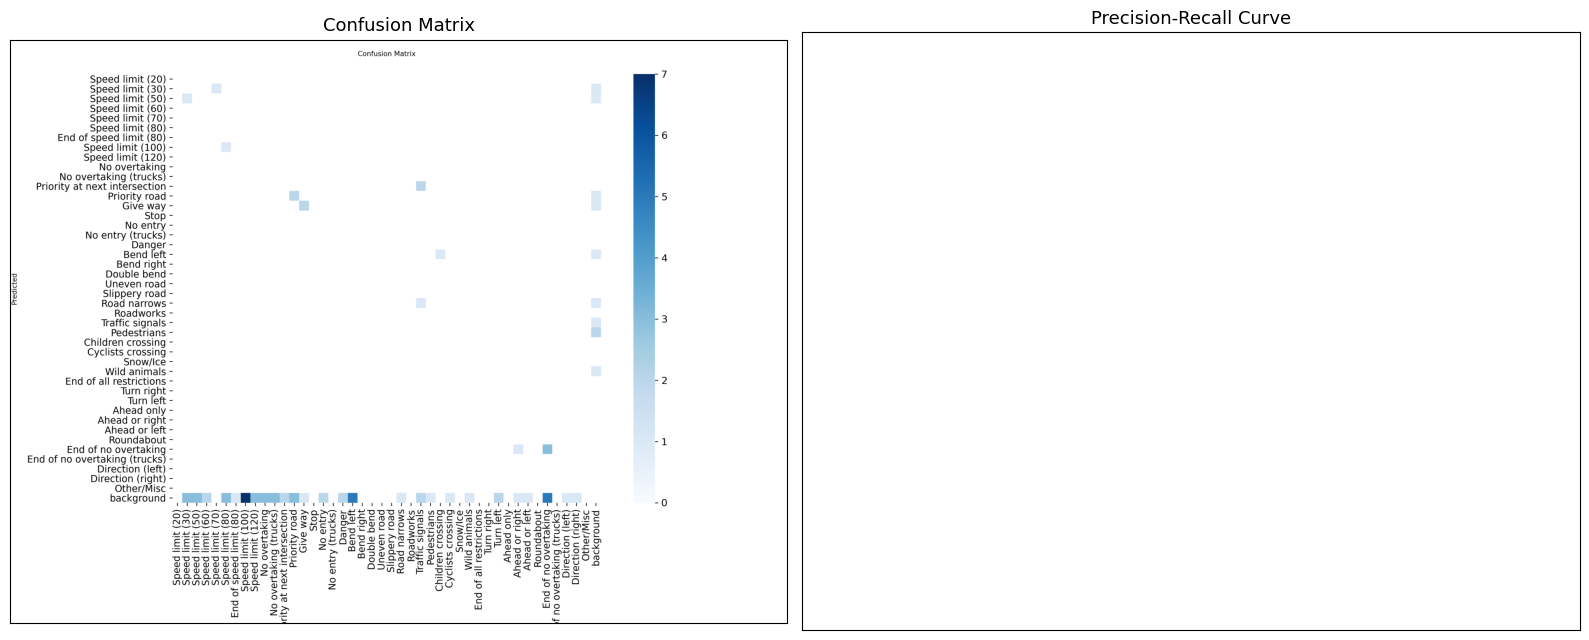

In [18]:
# Save the evaluation plot to assets/results.png

assets = ROOT / "assets"
assets.mkdir(exist_ok=True)

cm_path = list(ROOT.rglob("confusion_matrix.png"))
pr_path = list(ROOT.rglob("PR_curve.png"))

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
for ax, pat, title in [(axes[0], "confusion_matrix*.png", "Confusion Matrix"),
                       (axes[1], "PR_curve*.png", "Precision-Recall Curve")]:
    hits = [p for p in ROOT.rglob(pat)]
    if hits:
        ax.imshow(plt.imread(hits[0]))
    ax.set_title(title, fontsize=13)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.savefig(assets / "results.png", dpi=130, bbox_inches="tight")
print("Saved:", assets / "results.png")

# Record metrics into a small json the app/README can cite
import json
with open(assets / "metrics.json", "w") as f:
    json.dump({"mAP50": float(mAP50), "mAP50_95": float(mAP50_95),
               "precision": float(precision), "recall": float(recall),
               "fps": float(fps), "latency_ms": float(latency_ms)}, f, indent=2)
print("Saved: assets/metrics.json")

---
## 9. Bonus Work

1. **Export the model to ONNX** — `best.pt` → `best.onnx`. ONNX frees us from PyTorch and can be
   served by fast, lightweight runtimes (ONNX Runtime / TensorRT), cutting latency without a GPU.
2. **Confidence-threshold filter** — a user-facing knob that ignores low-quality detections: only
   boxes with `confidence >= threshold` survive. This is how production pipelines de-noise outputs.
3. **Webcam inference** — run the exported model live over a local camera feed, drawing + filtering
   boxes in real time (gated behind a `--webcam` flag so the shared Gradio demo still runs headless).

In [19]:
# Bonus 1 — export to ONNX (then we can also measure how much faster it is)
# if not present: !pip install -q onnx onnxslim
try:
    onnx_path = best.export(format="onnx", imgsz=IMG_SIZE, half=torch.cuda.is_available(),
                            opset=12, simplify=True, dynamic=False)
except Exception as e:
    print("Simplified export failed, retrying without simplify:", e)
    onnx_path = best.export(format="onnx", imgsz=IMG_SIZE, half=torch.cuda.is_available(),
                            opset=12, simplify=False, dynamic=False)
print("Exported:", onnx_path)

Ultralytics 8.3.241  Python-3.12.3 torch-2.11.0+cu128 CPU (AMD Ryzen 5 4600H with Radeon Graphics)



PyTorch: starting from 'D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 47, 8400) (6.0 MB)


requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...


Using Python 3.12.3 environment at: D:\summerToTheFinal\elevvo\elevvo_projects\task1\.venv
Resolved 5 packages in 691ms
 Downloaded onnxruntime-gpu
Prepared 1 package in 43.24s
         If the cache and target directories are on different filesystems, hardlinking may not be supported.
         If this is intentional, set `export UV_LINK_MODE=copy` or use `--link-mode=copy` to suppress this warning.
Installed 1 package in 2.56s
 + onnxruntime-gpu==1.29.0



requirements: AutoUpdate success  48.3s


...

ONNX: slimming with onnxslim 0.1.96...


ONNX: converting to FP16...


ONNX: export success  54.5s, saved as 'D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.onnx' (5.9 MB)



Export complete (55.1s)
Results saved to D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights
Predict:         yolo predict task=detect model=D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.onnx imgsz=640 half 
Validate:        yolo val task=detect model=D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.onnx imgsz=640 data=D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\data.yaml half 
Visualize:       https://netron.app


Exported: D:\summerToTheFinal\elevvo\elevvo_projects\task8-traffic-sign-recognition\runs\gtsdb_yolov8n\weights\best.onnx


In [20]:
# Bonus 1b — verify the ONNX export loads and measure its throughput if possible
try:
    import onnxruntime as ort
    session = ort.InferenceSession(str(onnx_path),
                                   providers=["CUDAExecutionProvider", "CPUExecutionProvider"])
    print("ONNX session ready:", session.get_inputs()[0].name,
          session.get_inputs()[0].shape, session.get_inputs()[0].type)
except ImportError:
    print("onnxruntime not installed - run  !pip install -q onnxruntime  to enable this check.")
    session = None
except Exception as e:
    print("ONNX session failed (export itself is already saved) - skipping runtime check:", e)
    session = None

if session is not None:
    def onnx_fps(imgs, iters=1):
        import time
        times = []
        for _ in range(iters):
            for img in imgs:
                im = cv2.imread(str(img))
                im = cv2.resize(im, (IMG_SIZE, IMG_SIZE))            # letterbox approx
                im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
                blob = im.astype(np.float32) / 255.0
                in_t = np.transpose(blob, (2, 0, 1))[None]            # HWC -> NCHW, batch 1
                t0 = time.time()
                _ = session.run(None, {session.get_inputs()[0].name: in_t})
                times.append(time.time() - t0)
        return len(imgs) * iters / sum(times) if times else 0.0

    try:
        print(f"ONNX-runtime approx FPS (640 letterbox, no pre/post loops): "
              f"{onnx_fps(list(test_imgs[:50])):.1f}")
    except Exception as e:
        print("ONNX-runtime FPS check skipped:", e)

ONNX session ready: images [1, 3, 640, 640] tensor(float)


ONNX-runtime approx FPS (640 letterbox, no pre/post loops): 23.8


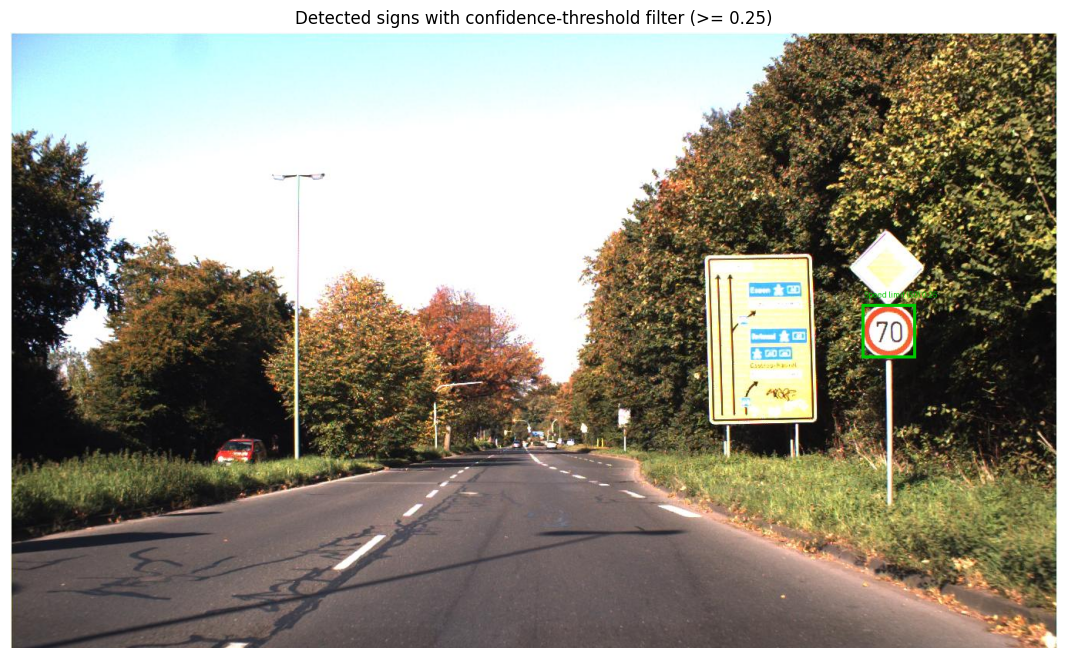

In [21]:
# Bonus 2 — confidence-threshold filter (visual demo on a test image)
def filter_detections(result, threshold):
    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    cls   = result.boxes.cls.cpu().numpy().astype(int)
    keep  = confs >= threshold
    return boxes[keep], confs[keep], cls[keep]

ex = best.predict(list(test_imgs)[40], imgsz=IMG_SIZE, device=DEVICE, conf=0.1,
                     verbose=False, workers=0)[0]
im = Image.open(ex.path).convert("RGB")
dr = ImageDraw.Draw(im)
W, H = im.size
for b, c_, i in zip(*filter_detections(ex, 0.25)):
    dr.rectangle(b.tolist(), outline=(0, 200, 0), width=4)
    dr.text((b[0]+3, b[1]-18), f"{CLASS_NAMES[i]} {c_:.2f}", fill=(0, 200, 0))
plt.figure(figsize=(14, 8))
plt.imshow(im); plt.axis("off")
plt.title("Detected signs with confidence-threshold filter (>= 0.25)")
plt.show()

In [22]:
# Bonus 3 — live webcam inference (run locally, not in Kaggle)
# app.py --webcam  /  or here:
import sys
def webcam_demo(conf=0.30, cam=0, fps_target=30):
    cap = cv2.VideoCapture(cam)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, 1280)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, 720)
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        res = best.predict(frame, imgsz=IMG_SIZE, device=DEVICE, conf=conf, verbose=False)[0]
        out = res.plot()                      # draws boxes + labels + confidences
        cv2.imshow("GTSDB Webcam (press q)", out)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release(); cv2.destroyAllWindows()

# Uncomment to run live (needs a local camera):
# webcam_demo()

## 10. Save Artifacts
The standalone `app.py` loads everything straight from `./models/` (no notebook dependency).
We copy the best weights and the ONNX export (if produced) there.

In [23]:
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)

# best torch weights
shutil.copy(ROOT / "runs" / "gtsdb_yolov8n" / "weights" / "best.pt",
            models_dir / "best.pt")

# ONNX export (bonus) if present
if Path(onnx_path).exists():
    shutil.copy(onnx_path, models_dir / "best.onnx")
    print("Saved best.onnx")

# class names used by the app
with open(models_dir / "class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

print("Artifacts in ./models/:")
for p in sorted(models_dir.iterdir()):
    print("  -", p.name, f"({p.stat().st_size/1e6:.2f} MB)")

Saved best.onnx
Artifacts in ./models/:
  - best.onnx (6.19 MB)
  - best.pt (6.25 MB)
  - class_names.json (0.00 MB)


## 11. Gradio Interface
Loads straight from the saved `./models/best.pt` (mirrors `app.py` exactly) and lets you upload an
image and see the bounding boxes + class labels + confidence overlaid. Launched with
`share=True` for a shareable link / screenshot.

In [24]:
import gradio as gr

model_app = YOLO(models_dir / "best.pt")   # independent of notebook training variables

def predict(image, conf=0.25):
    res = model_app.predict(image, imgsz=IMG_SIZE, device=DEVICE, conf=conf, verbose=False)[0]
    return res.plot()[:, :, ::-1]   # BGR -> RGB for display

with gr.Blocks(title="Task 8: Traffic Sign Recognition — Live Prediction") as demo:
    gr.Markdown("# Task 8: Traffic Sign Recognition — Live Prediction")
    gr.Markdown("**Industry constraint:** inference speed matters — this runs real-time. "
                "Use the confidence-threshold slider to ignore low-quality detections.")
    with gr.Row():
        with gr.Column():
            inp = gr.Image(type="pil", label="Full-resolution scene (upload)")
            conf_slider = gr.Slider(0.05, 0.9, value=0.25, step=0.05,
                                    label="Confidence threshold (bonus filter)")
            btn = gr.Button("Detect traffic signs")
        with gr.Column():
            out = gr.Image(label="Detected signs (boxes + class + confidence)")
    btn.click(predict, inputs=[inp, conf_slider], outputs=out)
    demo.launch(share=True)   # public link for the gradio_demo.png screenshot

* Running on local URL:  http://127.0.0.1:7860



Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
